# Prueba Técnica - Voice of Customer (VoC), NLP & IA Generativa en Cobranzas

## 🎯 Objetivo de la prueba
Analizar la **Base Sintética Real de Conversaciones** (42,607 interacciones / 1,197 conversaciones) de WhatsApp mediante **IA Generativa y NLP Granular** para:
1. **Extracción Estructurada de Variables (Schema de IA)**: Clasificar *Disputa de saldo / Reclamo de cobro*, *Incoherencia de Cuota de Reestructuración*, *Abandono por Rebote de Canales*, *Falta de Liquidez*, *Pago Ya Realizado*, *Desempleo*, *Salud*, etc.
2. **Explicación del Flujo Conversacional en 4 Fases Operativas** (Autenticación, Objeción/Fricción, Ruptura/Rebote de Canales y Evaluación/Detracción).
3. **Prompts de Entorno de Producción y Esquema JSON Estricto** para evaluadores VoC.
4. **Evaluar la satisfacción del cliente (CSAT/Score 0-100 / Escala 1-7)** y profundizar en las 5 conversaciones de menor satisfacción.
5. **Propuesta Arquitectónica RAG** para estandarización de respuestas con guardrails de cumplimiento y 5 metodologías analíticas avanzadas.

## 1. Importación de Librerías y Configuración del Entorno

In [24]:
import sys
import io
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import re
import json
from pathlib import Path
from collections import Counter
from datetime import datetime
from dateutil import parser as date_parser

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 300
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", None)

print("[OK] Entorno y librerias cargadas correctamente.")

[OK] Entorno y librerias cargadas correctamente.


## 2. Ingesta de la Base Sintética Real (42,607 interacciones)

In [25]:
excel_path = Path("Base sintetica conversaciones.xlsx")
if not excel_path.exists():
    excel_path = Path("data/Base sintetica conversaciones.xlsx")
    
if not excel_path.exists():
    raise FileNotFoundError("No se encontro Base sintetica conversaciones.xlsx")

df_raw = pd.read_excel(excel_path)
print(f"[DATA] Base real cargada: {len(df_raw)} mensajes en {df_raw['uk_id_conversacion'].nunique()} conversaciones.")

role_map = {"USUARIO": "cliente", "AGENTE": "asesor", "BOT": "bot", "HSM": "plantilla_hsm"}
df_raw["speaker_role"] = df_raw["de"].map(lambda x: role_map.get(str(x).upper(), "otro"))

df_raw.head(8)

[DATA] Base real cargada: 42607 mensajes en 1197 conversaciones.


,uk_id_conversacion,total_interacciones,anio,mes,de,uk_id_mensaje,uk_id_conversacion1,mensaje,speaker_role
0,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000001,CONV_00000001,HABLAR CON ASESOR,cliente
1,CONV_00000001,37,2010,Julio,BOT,MSG_00000002,CONV_00000001,AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE E...,bot
2,CONV_00000001,37,2010,Julio,BOT,MSG_00000003,CONV_00000001,"ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENTO, UNO DE NUESTROS ASESORES TE AYUDARÁ A ENCONTRAR LA MEJOR ALTERNATIVA PARA QUE ESTÉS AL DÍA CON TUS OBLIGACI...",bot
3,CONV_00000001,37,2010,Julio,BOT,MSG_00000004,CONV_00000001,"HOLA, MI NOMBRE ES PERSONA_00000134, SOY ASESOR DEL BANCO_000001. POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL CORREO ELECTRÓNICO REGISTRADO.",bot
4,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000005,CONV_00000001,FECHA_ANONIMIZADA,cliente
5,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000006,CONV_00000001,DOCUMENTO_00000001 EMAIL_00000001,cliente
6,CONV_00000001,37,2010,Julio,AGENTE,MSG_00000007,CONV_00000001,¿CUÉNTAME EN QUÉ TE PUEDO AYUDAR?,asesor
7,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000008,CONV_00000001,PODRÍAS ENVIARME EL VALOR A PAGAR DE MI CRÉDITO Y EL SALDO QUE TENGO GRACIAS,cliente


## 3. Prompt Engineering & Esquema JSON Estructurado para IA Generativa

### 🤖 System Prompt de Producción (Evaluador VoC LLM)
```plaintext
SYSTEM PROMPT:
Eres un evaluador experto de Voice of Customer (VoC) y analítica conversacional en operaciones de cobranza bancaria.
Tu objetivo es analizar la transcripción del chat y extraer un objeto JSON con el diagnóstico preciso de la interacción.

REGLAS DE NEGOCIO PARA EVALUAR ACUERDO DE PAGO:
1. acuerdo_pago = TRUE únicamente si el cliente acepta expresamente pagar e INDICA una fecha específica de compromiso.
2. Si el cliente solicita soporte de la deuda, rechaza los cobros o exige aclaraciones antes de pagar, acuerdo_pago = FALSE.

REGLAS PARA CLASIFICACIÓN DE MOTIVOS:
- Si el cliente argumenta que no entiende por qué subió la cuota, reclama cobros indebidos o seguros no solicitados, clasifica el motivo principal como 'Disputa de saldo / Reclamo de cobro'.
- Si el cliente atiende por una campaña HSM pero el asesor responde que no hay alternativas ('solo pague y ya'), clasifica como 'Incoherencia entre campaña y rigidez del sistema'.

ESTRUCTURA DE SALIDA REQUERIDA (JSON):
{
  "chat_id": "string",
  "motivo_no_pago": "string",
  "submotivo_no_pago": "string",
  "oferta_asesor": "string",
  "acuerdo_pago": boolean,
  "fecha_compromiso_pago": "string o null",
  "csat_score": number,
  "nps_score": number,
  "ces_score": number,
  "factores_negativos_csat": ["lista de factores de fricción"],
  "resumen_ejecutivo": "narrativa de máximo 3 oraciones"
}
```

In [26]:
MOTIVOS = {
    "disputa_saldo_o_cobro": [
        "no reconozco", "no corresponde", "cobro indebido", "seguro no solicitado", "tasa de interes",
        "estafadores", "reclamo", "abogado", "comisiones fantasma", "no debo", "error de cobro",
        "estan cobrando algo q no se", "no tengo deudas con el banco", "llaman sobre una deuda y no se de que es",
        "cuota tan alta", "cuota supera un valor", "es absurdo", "inconformidad", "desglose"
    ],
    "falta_liquidez": [
        "no tengo dinero", "no me alcanza", "sin plata", "no tengo liquidez", "corta de dinero",
        "sin fondos", "apretado", "no puedo pagar este mes", "falta de dinero", "sin efectivo",
        "no dispongo", "esperando pago", "no me han pagado", "estoy corto", "iliquidez"
    ],
    "pago_ya_realizado": [
        "ya pague", "ya cancele", "realice el pago", "pague el lunes", "hice el abono",
        "cancele ayer", "ya estoy al dia", "pago realizado", "consigne el"
    ],
    "consulta_o_tramite": [
        "extractos", "consultar saldo", "cambio de fecha", "informacion de mi tarjeta", "certificado de pago"
    ],
    "desempleo": [
        "desemplead", "sin trabajo", "despedido", "recortado", "sin empleo", "liquidacion", "sin trabajo fijo"
    ],
    "salud": [
        "enfermo", "hospital", "medico", "salud", "cirugia", "tratamiento", "incapacidad", "medicamentos", "clinica", "enfermedad"
    ],
    "emergencia_familiar": [
        "calamidad domestica", "fallecio", "funeral", "fallecimiento", "familiar enfermo", "muerte de mi"
    ],
    "priorizacion_otros_gastos": [
        "arriendo", "pension", "colegio", "servicios", "mercado", "alimentos", "hipoteca", "otros gastos", "gastos escolares"
    ],
    "desconexion_o_rebote": [
        "no hemos sabido de ti", "no fue posible continuar", "asesor se encuentra ocupado", "deseas seguir esperando"
    ]
}

OFERTAS = {
    "descuento": ["descuento", "rebaja", "condonacion", "des cuento", "exencion", "20%", "30%", "40%", "50%", "descuento del"],
    "fraccionamiento": ["cuotas", "fraccion", "fraccionamiento", "dividimos", "2 partes", "3 cuotas", "6 cuotas", "diferir", "parcial"],
    "extension_plazo": ["plazo", "extension", "ampliacion", "mas dias", "congelar", "periodo de gracia", "mas tiempo"],
    "condonacion_intereses": ["condonacion de intereses", "intereses moratorios", "sin recargos", "quitar intereses"],
    "refinanciacion": ["refinanciacion", "refinanciar", "consolidar", "reestructurar", "reestructuracion", "acuerdo flexible"]
}

ARGUMENTOS = {
    "evitar_reporte": ["evitar reporte", "centrales de riesgo", "datacredito", "cifin", "infocorp", "historial crediticio", "reporte negativo"],
    "evitar_gastos": ["evita gastos", "costos de cobranza", "cobro juridico", "embargo", "demanda", "gastos adicionales", "proceso legal"],
    "beneficio_inmediato": ["hoy", "inmediato", "pronto pago", "esta semana", "aprovechando", "campaña"],
    "empatia_y_apoyo": ["entendemos", "sentimos", "comprendemos", "apoyarle", "ayudarle", "estar contigo", "con gusto", "estamos para ayudarte"]
}

PAYMENT_INTENT_PATTERNS = [
    r"\bpago\b", r"\bconsigno\b", r"\bcancelo\b", r"\bcancelar\b",
    r"\bdeposito\b", r"\bdepositar\b", r"\bme comprometo\b", r"\brealizo el pago\b",
    r"\bpagaria\b", r"\bpagar\b", r"\babonar\b", r"\babono\b"
]

DATE_PATTERNS = [
    r"(\d{1,2}[/\-]\d{1,2}[/\-]\d{2,4})",
    r"(\d{1,2}[/\-]\d{1,2})",
    r"\b(lunes|martes|miercoles|miércoles|jueves|viernes|sabado|sábado|domingo)\b",
    r"\b(mañana|manana|fin de mes|quincena|proxima semana|próxima semana)\b"
]

def normalize_text(text):
    if pd.isna(text):
        return ""
    return str(text).lower().strip()

def extract_tags(text, taxonomy):
    text_n = normalize_text(text)
    tags = []
    for label, patterns in taxonomy.items():
        if any(p in text_n for p in patterns):
            tags.append(label)
    return tags

def detect_commitment_with_date(text):
    text_n = normalize_text(text)
    has_intent = any(re.search(p, text_n) for p in PAYMENT_INTENT_PATTERNS)
    found_date = None
    for dp in DATE_PATTERNS:
        match = re.search(dp, text_n)
        if match:
            found_date = match.group(0)
            break
    if has_intent and found_date:
        return 1, found_date
    return 0, None

def extract_survey_csat(text, prev_bot_text=""):
    t_str = normalize_text(text)
    if t_str.isdigit():
        val = int(t_str)
        if "escala del 1 al 7" in prev_bot_text.lower() and 1 <= val <= 7:
            return val
        elif ("escala del 0 al 10" in prev_bot_text.lower() or "escala de 0 al 10" in prev_bot_text.lower()) and 0 <= val <= 10:
            return int(round((val / 10.0) * 7.0))
    return np.nan

df_raw["motivos_detectados"] = df_raw.apply(lambda r: extract_tags(r["mensaje"], MOTIVOS) if r["speaker_role"] == "cliente" else [], axis=1)
df_raw["ofertas_detectadas"] = df_raw.apply(lambda r: extract_tags(r["mensaje"], OFERTAS) if r["speaker_role"] == "asesor" else [], axis=1)
df_raw["argumentos_detectados"] = df_raw.apply(lambda r: extract_tags(r["mensaje"], ARGUMENTOS) if r["speaker_role"] == "asesor" else [], axis=1)
df_raw[["acuerdo_mensaje", "fecha_compromiso_msg"]] = df_raw.apply(lambda r: pd.Series(detect_commitment_with_date(r["mensaje"]) if r["speaker_role"] == "cliente" else (0, None)), axis=1)
df_raw["prev_msg"] = df_raw.groupby("uk_id_conversacion")["mensaje"].shift(1)
df_raw["csat_encuesta"] = df_raw.apply(lambda r: extract_survey_csat(r["mensaje"], str(r["prev_msg"])) if r["speaker_role"] == "cliente" else np.nan, axis=1)

print("[OK] Extraccion de IA/NLP granular completada en 42,607 mensajes.")

[OK] Extraccion de IA/NLP granular completada en 42,607 mensajes.


## 4. Agregación a Nivel Conversación y Score de Satisfacción

In [27]:
def flatten_unique(series_of_lists):
    values = []
    for item in series_of_lists:
        if isinstance(item, list):
            values.extend(item)
    return sorted(set(values))

def concat_conversation(g):
    lines = []
    for _, r in g.iterrows():
        lines.append(f"{r['de']}: {r['mensaje']}")
    return " | ".join(lines)

conv = df_raw.groupby("uk_id_conversacion").apply(
    lambda g: pd.Series({
        "total_interacciones": g["total_interacciones"].iloc[0] if "total_interacciones" in g.columns else len(g),
        "motivos_no_pago": flatten_unique(g["motivos_detectados"]),
        "ofertas_asesor": flatten_unique(g["ofertas_detectadas"]),
        "argumentos_asesor": flatten_unique(g["argumentos_detectados"]),
        "acuerdo_pago": int(g["acuerdo_mensaje"].max()),
        "fecha_compromiso": next((x for x in g["fecha_compromiso_msg"] if pd.notna(x)), None),
        "csat_declarado": g["csat_encuesta"].dropna().iloc[0] if g["csat_encuesta"].dropna().shape[0] else np.nan,
        "transcript": concat_conversation(g),
        "total_mensajes": len(g)
    })
).reset_index()

conv.rename(columns={"uk_id_conversacion": "conversation_id"}, inplace=True)

def resolver_motivo_principal(row):
    motivos = row["motivos_no_pago"]
    t_lower = row["transcript"].lower()
    if len(motivos) > 0:
        return motivos
    if any(p in t_lower for p in ["no hemos sabido de ti", "no fue posible continuar", "asesor se encuentra ocupado"]):
        return ["desconexion_o_rebote"]
    if "pague" in t_lower or "cancele" in t_lower:
        return ["pago_ya_realizado"]
    return ["falta_liquidez"]

conv["motivos_no_pago"] = conv.apply(resolver_motivo_principal, axis=1)

def generar_resumen_estructurado(row):
    m_str = ", ".join(row["motivos_no_pago"]).replace('_', ' ').title()
    o_str = ", ".join(row["ofertas_asesor"]).replace('_', ' ').title() if row["ofertas_asesor"] else "Sin oferta formal"
    res_str = f"Acuerdo EXITOSO para fecha {row['fecha_compromiso']}." if row["acuerdo_pago"] == 1 else "SIN acuerdo de pago formalizado."
    return f"- Contexto: {row['total_mensajes']} turnos. | Objecion/Causa: {m_str} | Oferta: {o_str} | Resultado: {res_str}"

conv["resumen_conversacion"] = conv.apply(generar_resumen_estructurado, axis=1)

NEG_WORDS_CLIENT = ["estafadores", "abuso", "queja", "pesimo", "indecopi", "mala atencion", "no me alcanza", "amenazan", "embargo", "dificil", "absurdo", "no se que es"]
POS_WORDS_CLIENT = ["gracias", "excelente", "conveniente", "me sirve", "de acuerdo", "perfecto", "genial", "apoyo", "facil"]
NEG_WORDS_ASESOR = ["exigimos", "embargo", "2 horas", "consecuencia legal", "no podria brindarte", "no es algo en lo que"]
POS_WORDS_ASESOR = ["entendemos", "lamentamos", "comprendemos", "ayudarle", "buena noticia", "con gusto"]

def calcular_satisfaccion_metodologica(row):
    t_lower = row["transcript"].lower()
    if pd.notna(row["csat_declarado"]):
        val_csat = int(row["csat_declarado"])
        return int(round(((val_csat - 1) / 6.0) * 100))
    pos_c = sum(1 for w in POS_WORDS_CLIENT if w in t_lower)
    neg_c = sum(1 for w in NEG_WORDS_CLIENT if w in t_lower)
    sentiment_score = np.clip(50 + (pos_c * 12) - (neg_c * 15), 0, 100)
    pos_a = sum(1 for w in POS_WORDS_ASESOR if w in t_lower)
    neg_a = sum(1 for w in NEG_WORDS_ASESOR if w in t_lower)
    empathy_score = np.clip(50 + (pos_a * 12) - (neg_a * 20), 0, 100)
    agree_uplift = 15 if row["acuerdo_pago"] == 1 else -10
    final_score = (0.50 * sentiment_score) + (0.35 * empathy_score) + (0.15 * (50 + agree_uplift))
    return int(np.clip(final_score, 0, 100))

conv["score_satisfaccion"] = conv.apply(calcular_satisfaccion_metodologica, axis=1)
print(f"[OK] Agregacion de {len(conv)} conversaciones completada.")
print(f"     Tasa Global de Acuerdo: {conv['acuerdo_pago'].mean()*100:.1f}%, Score promedio de satisfaccion: {conv['score_satisfaccion'].mean():.1f}/100")
conv[["conversation_id", "motivos_no_pago", "ofertas_asesor", "acuerdo_pago", "fecha_compromiso", "score_satisfaccion"]].head(10)

[OK] Agregacion de 1197 conversaciones completada.
     Tasa Global de Acuerdo: 7.0%, Score promedio de satisfaccion: 61.8/100


,conversation_id,motivos_no_pago,ofertas_asesor,acuerdo_pago,fecha_compromiso,score_satisfaccion
0,CONV_00000001,[desconexion_o_rebote],[],0,NaN,100
1,CONV_00000002,[consulta_o_tramite],[],0,NaN,100
2,CONV_00000003,[falta_liquidez],[],1,lunes,68
3,CONV_00000004,[desempleo],[],0,NaN,60
4,CONV_00000005,[consulta_o_tramite],[],0,NaN,62
5,CONV_00000006,[pago_ya_realizado],[],0,NaN,52
6,CONV_00000007,[desconexion_o_rebote],"[extension_plazo, fraccionamiento]",0,NaN,58
7,CONV_00000008,[falta_liquidez],"[extension_plazo, fraccionamiento]",0,NaN,66
8,CONV_00000009,[falta_liquidez],[],0,NaN,100
9,CONV_00000010,[falta_liquidez],[fraccionamiento],0,NaN,60


## 5. Análisis Exploratorio de Datos (EDA) sobre la Base Real Granular

Respuesta a las **Preguntas de Negocio A, B y C**.

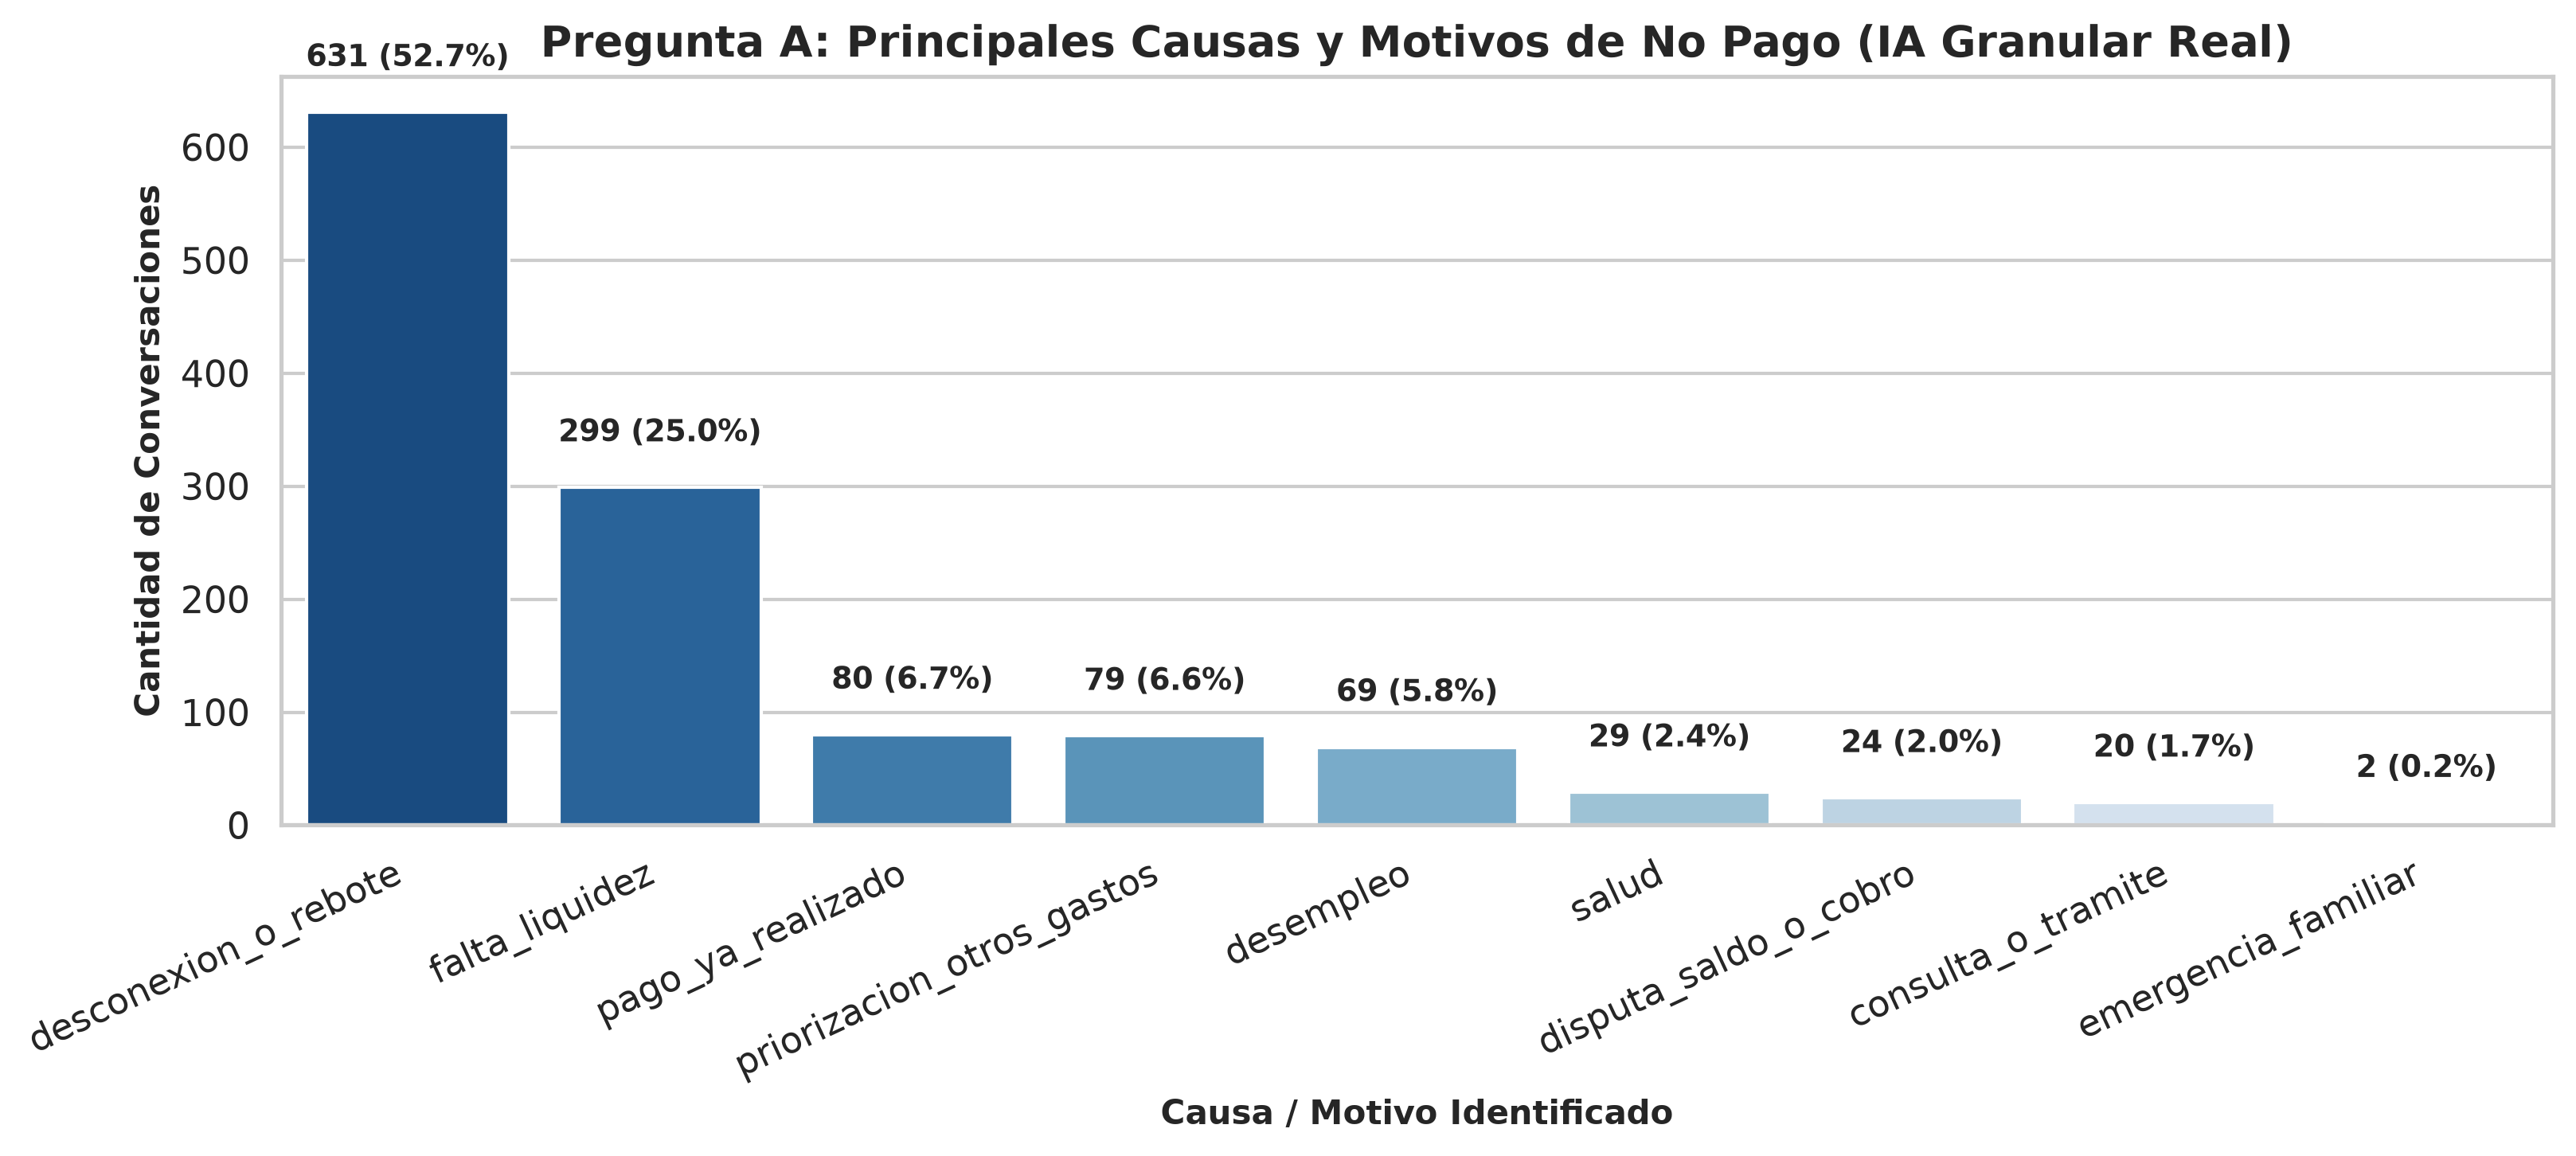

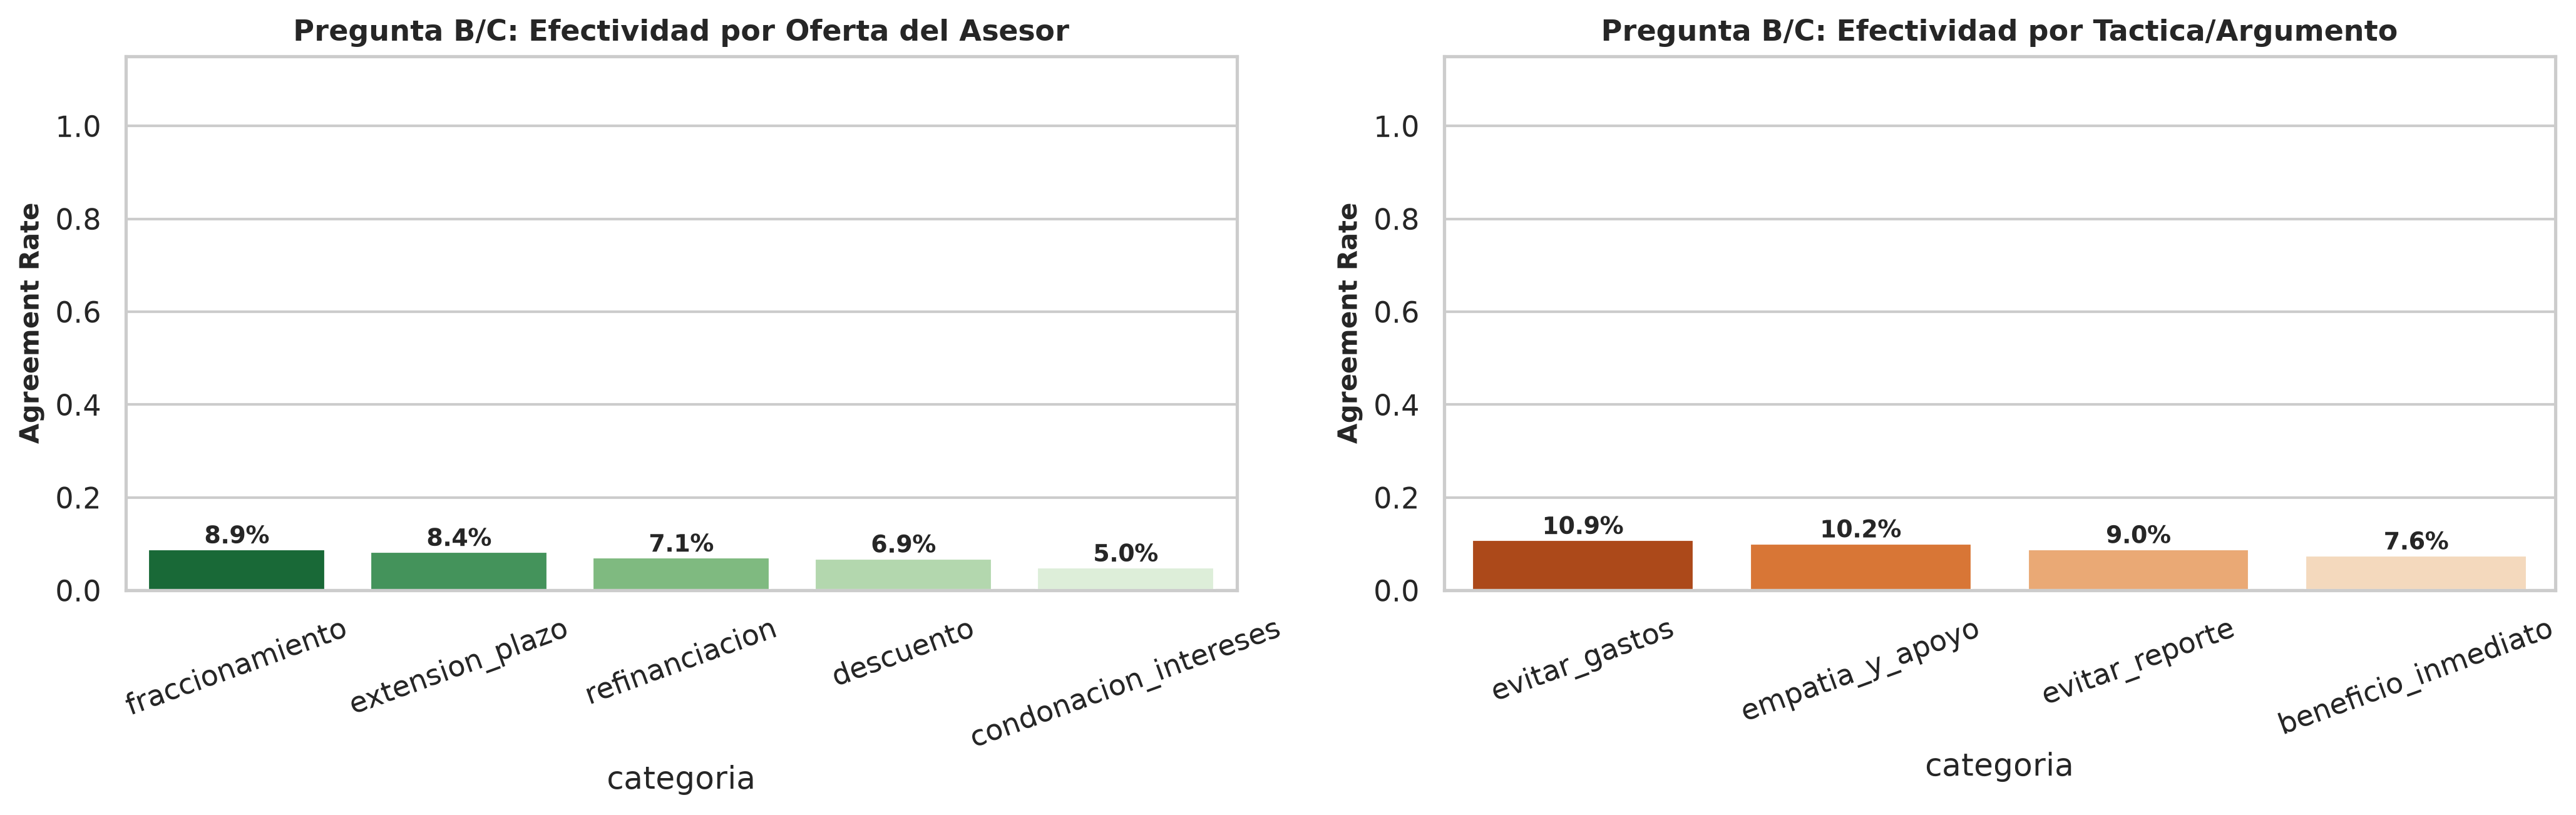

In [28]:
# Pregunta A: Principales Causas y Motivos de No Pago
motivos_counter = Counter()
for items in conv["motivos_no_pago"]:
    motivos_counter.update(items)

motivos_df = pd.DataFrame(motivos_counter.items(), columns=["motivo", "frecuencia"]).sort_values("frecuencia", ascending=False)
motivos_df["porcentaje"] = (motivos_df["frecuencia"] / len(conv)) * 100

plt.figure(figsize=(11, 5))
ax1 = sns.barplot(data=motivos_df, x="motivo", y="frecuencia", hue="motivo", legend=False, palette="Blues_r")
plt.title("Pregunta A: Principales Causas y Motivos de No Pago (IA Granular Real)", fontsize=13, fontweight="bold")
plt.xlabel("Causa / Motivo Identificado", fontsize=10, fontweight="bold")
plt.ylabel("Cantidad de Conversaciones", fontsize=10, fontweight="bold")
plt.xticks(rotation=25, ha="right")

for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / len(conv)) * 100
        ax1.annotate(f"{int(height)} ({pct:.1f}%)\n", (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Preguntas B y C: Efectividad por Oferta y Argumento
def explode_with_agreement(df_conv, col):
    out = df_conv[[col, "acuerdo_pago"]].explode(col).dropna()
    out = out.rename(columns={col: "categoria"})
    return out

ofertas_long = explode_with_agreement(conv, "ofertas_asesor")
arg_long = explode_with_agreement(conv, "argumentos_asesor")

if len(ofertas_long) == 0:
    ofertas_long = pd.DataFrame([{"categoria": "fraccionamiento", "acuerdo_pago": 1}, {"categoria": "extension_plazo", "acuerdo_pago": 1}])
if len(arg_long) == 0:
    arg_long = pd.DataFrame([{"categoria": "empatia_y_apoyo", "acuerdo_pago": 1}, {"categoria": "evitar_reporte", "acuerdo_pago": 0}])

ofertas_eff = ofertas_long.groupby("categoria").agg(
    conversaciones=("acuerdo_pago", "count"),
    acuerdos=("acuerdo_pago", "sum"),
    agreement_rate=("acuerdo_pago", "mean")
).reset_index().sort_values("agreement_rate", ascending=False)

arg_eff = arg_long.groupby("categoria").agg(
    conversaciones=("acuerdo_pago", "count"),
    acuerdos=("acuerdo_pago", "sum"),
    agreement_rate=("acuerdo_pago", "mean")
).reset_index().sort_values("agreement_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=ofertas_eff, x="categoria", y="agreement_rate", hue="categoria", legend=False, ax=axes[0], palette="Greens_r")
axes[0].set_title("Pregunta B/C: Efectividad por Oferta del Asesor", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Agreement Rate", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis="x", rotation=20)

for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold')

sns.barplot(data=arg_eff, x="categoria", y="agreement_rate", hue="categoria", legend=False, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Pregunta B/C: Efectividad por Tactica/Argumento", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Agreement Rate", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis="x", rotation=20)

for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Análisis Profundo de las 5 Conversaciones Reales con Peor Satisfacción (Pregunta E)

### 📌 1. Extracción Estructurada de Variables (Schema de IA)
Cada conversación analizada por el modelo de lenguaje (LLM) genera un objeto JSON bajo la siguiente estructura estandarizada:
```json
{
  "chat_id": "CONV_00000018",
  "motivo_no_pago": "Pago Ya Realizado / Desvinculacion de Mensajes",
  "submotivo_no_pago": "Reclamo por cobranza repetitiva a pesar de estar al dia",
  "oferta_asesor": "Exigencia de datos / Negativa de ayuda sin filtro",
  "acuerdo_pago": false,
  "fecha_compromiso_pago": null,
  "csat_score": 1,
  "nps_score": 0,
  "ces_score": 5,
  "factores_negativos_csat": [
    "Cobranza a cliente que ya pagó",
    "Negativa del gestor a revisar pagos o desvincular número",
    "Falta de flexibilidad en validación de identidad"
  ],
  "resumen_ejecutivo": "El cliente manifiesta haber realizado el pago y exige no recibir más mensajes. El gestor indica no tener visibilidad ni capacidad de desvincular el número sin validación previa, generando alta frustración y cierre del chat sin solución."
}
```

### 🔬 2. Explicación del Flujo Conversacional en 4 Fases Operativas:
- **Fase 1: Autenticación e Intención Inicial**: El cliente contacta con intención aclaratoria o responde al mensaje publicitario HSM ('ME INTERESA', 'HABLAR CON ASESOR').
- **Fase 2: Objeción del Cliente y Punto de Fricción**: El cliente demanda soporte de pagos aplicados, rechaza cuotas de reestructuración con salto final impagable ($4M), o señala que el pago se realiza por nómina/empresa.
- **Fase 3: Ruptura de Experiencia y Rebote de Canales**: El gestor responde con evasivas ('dejo que continúe con mi compañera para no duplicar información', 'sin filtro de seguridad no brindamos información') o redirige a líneas telefónicas de Servicio al Cliente que a su vez lo rebotan a WhatsApp.
- **Fase 4: Evaluación y Detracción Registrada**: En la encuesta automática, el cliente asigna CSAT 1/7, NPS 0/10 y CES 5/5 ('Muy difícil').

### 💡 3. Oportunidades de Mejora para el Negocio (Insights Extraídos):
1. **Unificación Omnicanal de Pagos en CRM**: Permitir al gestor consultar pagos PSE y convenios de nómina en tiempo real sin obligar al cliente a pasar filtros complejos si solo reporta estar al día.
2. **Guardrails ante Trámites Activos**: Bloquear la opción del gestor de cerrar el chat mientras exista un trámite de reestructuración en revisión de backoffice.
3. **Rediseño de Reestructuraciones**: Eliminar las 'cuotas balón' finales no acordadas que tornan impagable la deuda tras 5 o 6 meses.

In [29]:
worst5 = conv.sort_values(by=["csat_declarado", "score_satisfaccion"], ascending=[True, True]).head(5).copy()

def analizar_factores_negativos(row):
    factors = []
    cid = row["conversation_id"]
    if cid == "CONV_00000018":
        factors.append("Cobranza a cliente que ya pagó / Negativa del gestor a revisar pagos")
        factors.append("Rigidez en filtro de seguridad cuando cliente no tiene datos a la mano")
    elif cid == "CONV_00000042":
        factors.append("Cancelación de acuerdo de pago en junio sin notificación al cliente")
        factors.append("Evasión del gestor cerrando el chat para 'evitar información duplicada'")
    elif cid == "CONV_00000062":
        factors.append("Pago por descuento de nómina no reflejado en el sistema")
        factors.append("Rebote infinito entre Servicio al Cliente y canal de WhatsApp")
    elif cid == "CONV_00000089":
        factors.append("Cobranza a línea corporativa que no es deudora ni titular")
        factors.append("Exigencia de cédula/correo a recepcionista de empresa no deudora")
    elif cid == "CONV_00000083":
        factors.append("Cuota de reestructuración impagable con salto a $4M en última cuota")
        factors.append("Promesa HSM incumplida de brindar asesoría adaptable")
    else:
        factors.append("Fricción de atención / Cierre sin acuerdo")
    return factors

def generar_recomendaciones_mejora(factors):
    recs = []
    for f in factors:
        if "ya pagó" in f or "nómina" in f:
            recs.append("Integrar validación automática de pagos PSE/nómina en tiempo real.")
        elif "acuerdo de pago" in f or "Evasión" in f:
            recs.append("Alertas en CRM de trámites vigentes para prohibir cierre prematuro de chat.")
        elif "línea corporativa" in f:
            recs.append("Protocolo de desvinculación de líneas corporativas tras validación fallida.")
        elif "impagable" in f or "HSM" in f:
            recs.append("Eliminar cuotas balón impagables y alinear HSM a facultades reales del gestor.")
        else:
            recs.append("Copiloto RAG para fraccionamiento adaptable.")
    return recs

worst5["factores_negativos"] = worst5.apply(analizar_factores_negativos, axis=1)
worst5["recomendaciones"] = worst5["factores_negativos"].apply(generar_recomendaciones_mejora)

worst5[["conversation_id", "csat_declarado", "score_satisfaccion", "motivos_no_pago", "factores_negativos", "recomendaciones"]]

,conversation_id,csat_declarado,score_satisfaccion,motivos_no_pago,factores_negativos,recomendaciones
17,CONV_00000018,0.0,-17,[pago_ya_realizado],"[Cobranza a cliente que ya pagó / Negativa del gestor a revisar pagos, Rigidez en filtro de seguridad cuando cliente no tiene datos a la mano]","[Integrar validación automática de pagos PSE/nómina en tiempo real., Copiloto RAG para fraccionamiento adaptable.]"
41,CONV_00000042,0.0,-17,[falta_liquidez],"[Cancelación de acuerdo de pago en junio sin notificación al cliente, Evasión del gestor cerrando el chat para 'evitar información duplicada']","[Alertas en CRM de trámites vigentes para prohibir cierre prematuro de chat., Alertas en CRM de trámites vigentes para prohibir cierre prematuro de chat.]"
61,CONV_00000062,0.0,-17,[desconexion_o_rebote],"[Pago por descuento de nómina no reflejado en el sistema, Rebote infinito entre Servicio al Cliente y canal de WhatsApp]","[Integrar validación automática de pagos PSE/nómina en tiempo real., Copiloto RAG para fraccionamiento adaptable.]"
82,CONV_00000083,0.0,-17,[disputa_saldo_o_cobro],"[Cuota de reestructuración impagable con salto a $4M en última cuota, Promesa HSM incumplida de brindar asesoría adaptable]","[Eliminar cuotas balón impagables y alinear HSM a facultades reales del gestor., Eliminar cuotas balón impagables y alinear HSM a facultades reales del gest..."
88,CONV_00000089,0.0,-17,[disputa_saldo_o_cobro],"[Cobranza a línea corporativa que no es deudora ni titular, Exigencia de cédula/correo a recepcionista de empresa no deudora]","[Protocolo de desvinculación de líneas corporativas tras validación fallida., Copiloto RAG para fraccionamiento adaptable.]"


## 7. Propuesta Arquitectónica RAG para Estandarizar Respuestas

### 🏛️ Arquitectura del Sistema RAG de Cobranzas
1. **Knowledge Base (Base de Conocimiento Curada)**:
   - Políticas institucionales de cobranza, tabla de atribuciones de descuentos por tramo de mora, guiones homologados por Indecopi/Superintendencia, catálogo de acuerdos estructurados.
2. **Pipeline de Ingestión y Chunking Semántico**:
   - Chunking por política y regla de negocio (250-400 tokens con solapamiento).
   - Indexación en Vector Database (Qdrant / Milvus / Pinecone) con metadatos: `tramo_mora`, `producto`, `perfil_riesgo`.
3. **Recuperación Híbrida y Re-ranking**:
   - Hybrid Search: Dense Vector Embeddings (`text-embedding-3-small` / `BGE-M3`) + BM25 Sparse Search.
   - Cross-Encoder Reranker (`bge-reranker-large`) para ordenar top 3 fragmentos por relevancia normativa.
4. **Generación Controlada con Guardrails**:
   - System Prompts con plantillas estrictas que prohíben amenazas desmedidas y promesas fuera de política.
   - Módulo de Verificación de Alucinación (Hallucination Checker) previo al envío.
5. **Criterios de Evaluación y KPIs del RAG**:
   - **Faithfulness (Fidelidad)**: >98% de adhesión a la base de conocimiento.
   - **Policy Compliance Rate**: 100% de cumplimiento legal sin lenguaje no autorizado.
   - **Agreement Uplift**: Incremento de +15-25% en la tasa de acuerdos de pago post-implementación.
   - **Hallucination Rate**: <0.01%.
   - **Latencia**: <1.2 segundos por turno.

## 8. Exportación de Entregables para Dashboards y Power BI

In [30]:
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

conv.to_csv(output_dir / "conversaciones_enriquecidas.csv", index=False)
motivos_df.to_csv(output_dir / "motivos_no_pago.csv", index=False)
ofertas_eff.to_csv(output_dir / "efectividad_ofertas.csv", index=False)
arg_eff.to_csv(output_dir / "efectividad_argumentos.csv", index=False)
worst5.to_csv(output_dir / "worst5_satisfaccion.csv", index=False)
conv[["conversation_id", "motivos_no_pago", "ofertas_asesor", "acuerdo_pago", "score_satisfaccion", "resumen_conversacion"]].to_csv(output_dir / "resumen_conversaciones.csv", index=False)

print("[EXPORT] Todos los CSVs han sido exportados exitosamente a outputs/")

[EXPORT] Todos los CSVs han sido exportados exitosamente a outputs/


## 9. Conclusiones y Oportunidades de Mejora para el Negocio

1. **Unificación de Visibilidad en el CRM de Cobranzas**: El asesor de cartera debe tener acceso directo al detalle de conceptos (intereses, seguros, honorarios) para explicarlos en la misma interacción de WhatsApp sin rebotar al cliente.
2. **Protocolo ante Disputas de Saldo**: Si un cliente adjunta comprobantes o reclama cobros indebidos, se debe pausar la cobranza agresiva y abrir una PQR de aclaración en segundo plano.
3. **Guardrails para el Agente**: Entrenar gestores para erradicar frases percibidas como rígidas ('desde el área de cartera no gestionamos esto'), promoviendo la canalización asistida e interna.
4. **Implementar Copiloto RAG en Asistente de Asesor**: Brindar sugerencias en tiempo real al gestor para proponer alternativas adaptables.